<a href="https://colab.research.google.com/github/ahcamachod/2257-fundamentos-ia-explorando-algoritmos-y-enfoques-de-ml/blob/aula-3/fundamentos_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clase 1**

## Aprendizaje Supervisado - Clasificación

In [1]:
# Paso 1: Importar las bibliotecas necesarias
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Paso 2: Cargar el dataset Iris
iris = load_iris()
X = iris.data  # Características (largo y ancho de pétalos y sépalos)
y = iris.target  # Rótulos (especies de flores)

# Paso 3: Dividir los datos para entrenamiento y para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Paso 4: Entrenar el modelo
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Paso 5: Realizar previsiones y evaluar el modelo
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy * 100:.2f}%")

Exactitud del modelo: 100.00%


In [2]:
# Paso 1: Importar las bibliotecas necesarias
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import pandas as pd

# Paso 2: Cargar y preparar el dataset Iris
dataset = load_iris()
df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
df['species'] = dataset.target

# Paso 3: Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['species']))

# Paso 4: Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['species'], test_size=0.3, random_state=42)

# Paso 5: Entrenar y evaluar el árbol de decisión
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
tree_accuracy = accuracy_score(y_test, tree_model.predict(X_test))
print(f"Exactitud del modelo de Árbol de Decisión: {tree_accuracy * 100:.2f}%")

# Paso 6: Entrenar y evaluar el KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
knn_accuracy = accuracy_score(y_test, knn_model.predict(X_test))
print(f"Exactitud del modelo KNN: {knn_accuracy * 100:.2f}%")

Exactitud del modelo de Árbol de Decisión: 100.00%
Exactitud del modelo KNN: 100.00%


## Aprendizaje Supervisado - Regresión

Coeficiente angular (b1): 19.43
Intercepto (b0): 514.29

Métricas de Evaluación:
R² en datos de prueba: 0.94
Erro Medio Absoluto (MAE): 7.39
Raíz del Error Cuadrático Medio (RMSE): 9.34

Promedio de los puntajes de la validación cruzada: 0.95


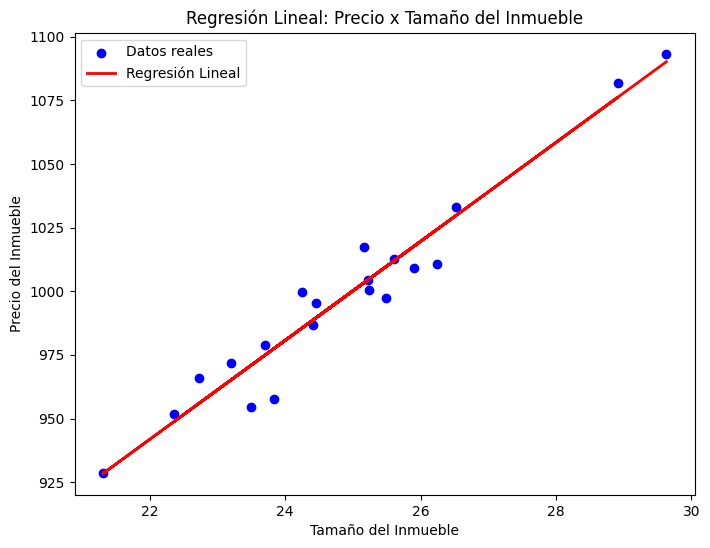

In [4]:
# Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Creando un conjunto de datos simulados
np.random.seed(42)
X = 2.5 * np.random.randn(100, 1) + 25  # Tamaño del inmueble (m2)
y = 500 + (X * 20) + np.random.randn(100, 1) * 10  # Precio del inmueble (miles de dólares)

# Definiendo features (independientes) y labels (dependientes)
features = X
labels = y

# Dividiendo los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Creando y entrenando el modelo
model = LinearRegression()
model.fit(X_train, y_train)

#Modelo de Regresión lineal
# Y = A X + B
# Y -> Variable de salida
# X -> Tamaño del inmueble
# A y B son los coeficientes

# Coeficientes de Regresión
print(f"Coeficiente angular (b1): {model.coef_[0][0]:.2f}")
print(f"Intercepto (b0): {model.intercept_[0]:.2f}")

# Predicciones con los datos de prueba
y_pred = model.predict(X_test)

# Indicadores de la Evaluación del modelo con los datos de prueba
#R² Ajuste de los datos al modelo
r2 = r2_score(y_test, y_pred)
#MAE (Error Medio Absoluto)
mae = mean_absolute_error(y_test, y_pred)
#RMSE (Raíz del error Cuadrático Medio)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nMétricas de Evaluación:")
print(f"R² en datos de prueba: {r2:.2f}")
print(f"Erro Medio Absoluto (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

# Evaluación cruzada
cv_scores = cross_val_score(model, features, labels, cv=5, scoring='r2')
print(f"\nPromedio de los puntajes de la validación cruzada: {cv_scores.mean():.2f}")

# Gráfico de la recta de Regresión
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regresión Lineal')
plt.xlabel("Tamaño del Inmueble")
plt.ylabel("Precio del Inmueble")
plt.title("Regresión Lineal: Precio x Tamaño del Inmueble")
plt.legend()
plt.show()

# **Clase 2**

## Ejemplos de Clasificación y Regresión

In [5]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

# Ver las primeras 5 filas de los datos
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Error Cuadrático Medio (MSE): 0.53
Coeficiente de Determinación (R²): 0.60


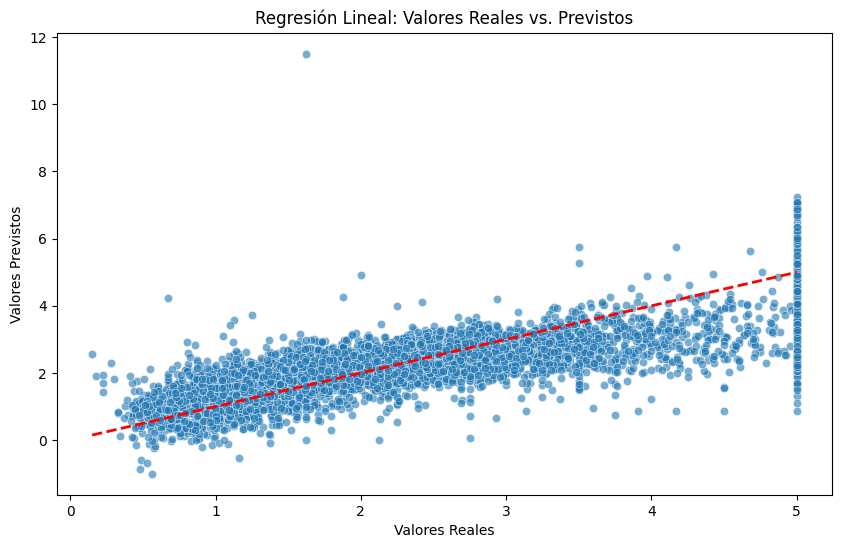

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Cargar el conjunto de datos
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

# Dividir los datos en datos de entrenamiento y de prueba
X = df.drop('PRICE', axis=1)
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar la previsión
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Exhibir las métricas
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

# Visualización de los resultados
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)  # Línea de referencia
plt.xlabel("Valores Reales")
plt.ylabel("Valores Previstos")
plt.title("Regresión Lineal: Valores Reales vs. Previstos")
plt.show()

In [8]:
from sklearn.datasets import load_diabetes

# Cargar los datos
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Ver las primeras 5 filas de los datos
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Exactitud del Modelo: 80.45%


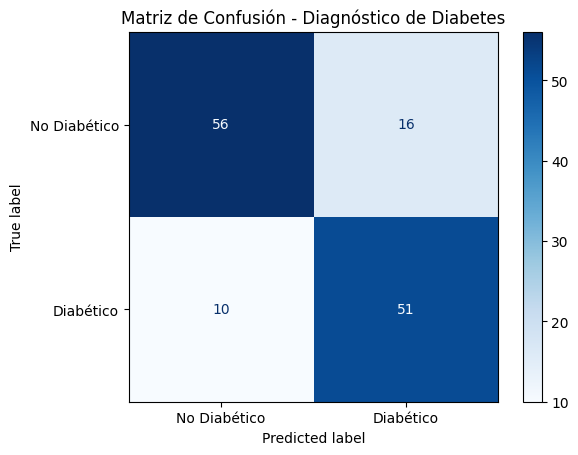

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Cargar los datos
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['OUTCOME'] = diabetes.target

# Transformar la variable target en binaria (clasificación)
df['OUTCOME'] = (df['OUTCOME'] > df['OUTCOME'].median()).astype(int)  # 1 cuando es superior a la mediana, y 0 cuando es inferior

# Dividir los datos en datos de entrenamiento y datos de prueba
X = df.drop('OUTCOME', axis=1)
y = df['OUTCOME']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar el modelo
model = LogisticRegression(max_iter=1000)  # Aumentando las iteraciones para evitar warnings
model.fit(X_train, y_train)

# Realizar la Previsión
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del Modelo: {accuracy * 100:.2f}%")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabético', 'Diabético'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Diagnóstico de Diabetes")
plt.show()

In [10]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Cargar dataset
X, y = fetch_california_housing(return_X_y=True)

# Dividir en datos de entrenamiento y datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Definir los hiperparámetros para optimizarlos
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#max_depth -> profundidad máxima del árbol de decisión
#'min_samples_split' -> nº mínimo de muestras para dividir el nodo
#'min_samples_leaf' -> nº mínimo de muestras por hoja

# Aplicar GridSearch para encontrar los mejores hiperparámetros
grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

#GridSearch -> Realiza la búsqueda de los mejores hiperparámetros combinando todos los valores de hiperparámetros
# Métrica de evaluación -> Error Cuadrático Medio Negativo
print(f"Mejores parámetros: {grid_search.best_params_}")

Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


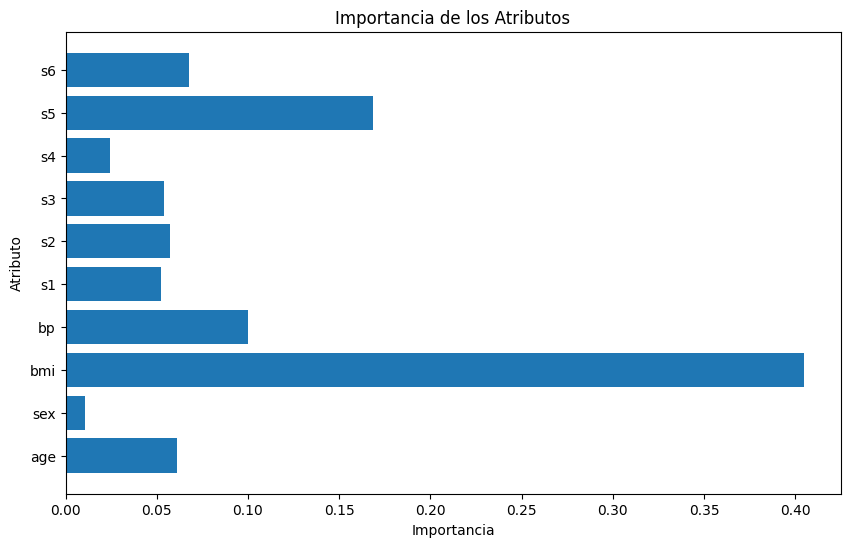

In [11]:
# Importar bibliotecas
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Cargar el dataset Diabetes
diabetes = load_diabetes()
X = diabetes.data  # Variables independientes
y = diabetes.target  # Variable dependiente

# Dividir los datos para entrenamiento y para prueba (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Obtener la importancia de los atributos
importances = model.feature_importances_
feature_names = diabetes.feature_names

# Crear un gráfico de barras para visualizar la importancia de los atributos
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.title("Importancia de los Atributos")
plt.xlabel("Importancia")
plt.ylabel("Atributo")
plt.show()

Random Forest - MSE: 0.29, R²: 0.78
Gradient Boosting - MSE: 0.24, R²: 0.82


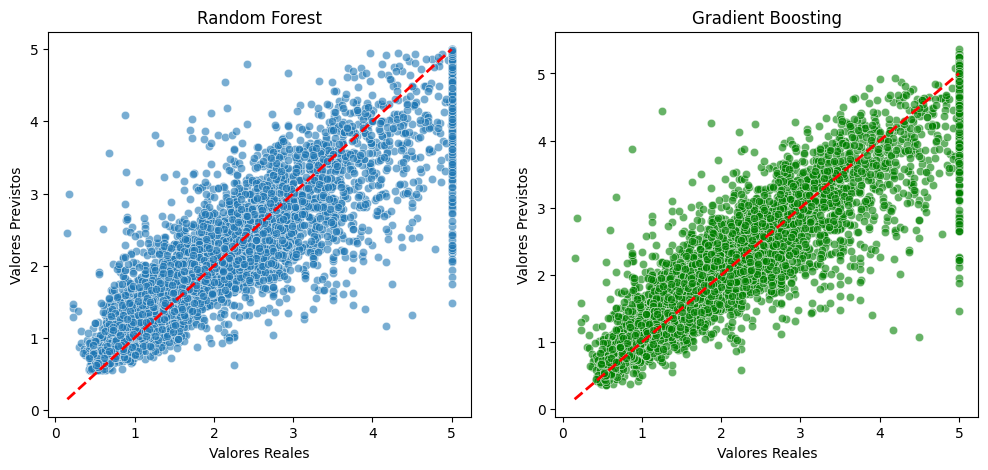

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Cargar el conjunto de datos
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

# Dividir los datos en entrenamiento y prueba
X = df.drop('PRICE', axis=1)
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y entrenar los modelos ensemble (Ensamblados)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Realizar previsiones
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# Evaluar los modelos
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Exhibir métricas
print(f"Random Forest - MSE: {mse_rf:.2f}, R²: {r2_rf:.2f}")
print(f"Gradient Boosting - MSE: {mse_gb:.2f}, R²: {r2_gb:.2f}")

# Visualizar los resultados
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Previstos")
plt.title("Random Forest")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_gb, alpha=0.6, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Previstos")
plt.title("Gradient Boosting")

plt.show()

# **Clase 3**

## Aprendizaje No Supervisado - Clustering